# Bài 1: Cây quyết định ID3 – dữ liệu buys_computer
Dự đoán khách hàng có mua máy tính hay không (`buys_computer`) dựa trên 4 thuộc tính: `age`, `income`, `student`, `credit_rating`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Dữ liệu
14 mẫu, nhãn gồm 9 `yes` và 5 `no`.

In [2]:
rows = [
    ('<=30', 'high', 'no', 'fair', 'no'),
    ('<=30', 'high', 'no', 'excellent', 'no'),
    ('31…40', 'high', 'no', 'fair', 'yes'),
    ('>40', 'medium', 'no', 'fair', 'yes'),
    ('>40', 'low', 'yes', 'fair', 'yes'),
    ('>40', 'low', 'yes', 'excellent', 'no'),
    ('31…40', 'low', 'yes', 'excellent', 'yes'),
    ('<=30', 'medium', 'no', 'fair', 'no'),
    ('<=30', 'low', 'yes', 'fair', 'yes'),
    ('>40', 'medium', 'yes', 'fair', 'yes'),
    ('<=30', 'medium', 'yes', 'excellent', 'yes'),
    ('31…40', 'medium', 'no', 'excellent', 'yes'),
    ('31…40', 'high', 'yes', 'fair', 'yes'),
    ('>40', 'medium', 'no', 'excellent', 'no')
]
data = pd.DataFrame(rows, columns=['age', 'income', 'student', 'credit_rating', 'buys_computer'])
data.index = range(1, len(data) + 1)

TARGET = "buys_computer"
ATTRS = ["age", "income", "student", "credit_rating"]
# Thứ tự hiển thị các giá trị của từng thuộc tính
ORDERS = {'age': ['<=30', '31…40', '>40'], 'income': ['low', 'medium', 'high'], 'student': ['no', 'yes'], 'credit_rating': ['fair', 'excellent']}
data

,age,income,student,credit_rating,buys_computer
1,<=30,high,no,fair,no
2,<=30,high,no,excellent,no
3,31…40,high,no,fair,yes
4,>40,medium,no,fair,yes
5,>40,low,yes,fair,yes
6,>40,low,yes,excellent,no
7,31…40,low,yes,excellent,yes
8,<=30,medium,no,fair,no
9,<=30,low,yes,fair,yes
10,>40,medium,yes,fair,yes


## Lời giải tay
Công thức:

$$Entropy(S) = -\sum_i p_i \log_2 p_i \qquad Gain(S, A) = Entropy(S) - \sum_{v} \frac{|S_v|}{|S|} Entropy(S_v)$$

Các bước 1–4: tính Entropy, lập bảng đếm và tính Gain cho từng thuộc tính, chọn thuộc tính có Gain lớn nhất, rồi lặp lại cho từng nhánh con.

#### Nút: Toàn bộ tập dữ liệu (14 mẫu: 9 × yes, 5 × no)
$$Entropy(S) = -\frac{9}{14}\log_2\frac{9}{14} - \frac{5}{14}\log_2\frac{5}{14} = 0.940$$

**Thuộc tính age**

| Giá trị | Số mẫu yes | Số mẫu no | Tổng | Entropy |
|---|---|---|---|---|
| <=30 | 2 | 3 | 5 | 0.971 |
| 31…40 | 4 | 0 | 4 | -0.000 |
| >40 | 3 | 2 | 5 | 0.971 |

$$Gain(S, \text{age}) = 0.940 - (\frac{5}{14}\cdot0.971 + \frac{4}{14}\cdot-0.000 + \frac{5}{14}\cdot0.971) = 0.247$$

**Thuộc tính income**

| Giá trị | Số mẫu yes | Số mẫu no | Tổng | Entropy |
|---|---|---|---|---|
| low | 3 | 1 | 4 | 0.811 |
| medium | 4 | 2 | 6 | 0.918 |
| high | 2 | 2 | 4 | 1.000 |

$$Gain(S, \text{income}) = 0.940 - (\frac{4}{14}\cdot0.811 + \frac{6}{14}\cdot0.918 + \frac{4}{14}\cdot1.000) = 0.029$$

**Thuộc tính student**

| Giá trị | Số mẫu yes | Số mẫu no | Tổng | Entropy |
|---|---|---|---|---|
| no | 3 | 4 | 7 | 0.985 |
| yes | 6 | 1 | 7 | 0.592 |

$$Gain(S, \text{student}) = 0.940 - (\frac{7}{14}\cdot0.985 + \frac{7}{14}\cdot0.592) = 0.152$$

**Thuộc tính credit_rating**

| Giá trị | Số mẫu yes | Số mẫu no | Tổng | Entropy |
|---|---|---|---|---|
| fair | 6 | 2 | 8 | 0.811 |
| excellent | 3 | 3 | 6 | 1.000 |

$$Gain(S, \text{credit_rating}) = 0.940 - (\frac{8}{14}\cdot0.811 + \frac{6}{14}\cdot1.000) = 0.048$$

⇒ Gain lớn nhất: **age = 0.247** ⇒ chọn **age** để chia nút.

#### Nút: age = <=30 (5 mẫu: 2 × yes, 3 × no)
$$Entropy(S) = -\frac{2}{5}\log_2\frac{2}{5} - \frac{3}{5}\log_2\frac{3}{5} = 0.971$$

**Thuộc tính income**

| Giá trị | Số mẫu yes | Số mẫu no | Tổng | Entropy |
|---|---|---|---|---|
| low | 1 | 0 | 1 | -0.000 |
| medium | 1 | 1 | 2 | 1.000 |
| high | 0 | 2 | 2 | -0.000 |

$$Gain(S, \text{income}) = 0.971 - (\frac{1}{5}\cdot-0.000 + \frac{2}{5}\cdot1.000 + \frac{2}{5}\cdot-0.000) = 0.571$$

**Thuộc tính student**

| Giá trị | Số mẫu yes | Số mẫu no | Tổng | Entropy |
|---|---|---|---|---|
| no | 0 | 3 | 3 | -0.000 |
| yes | 2 | 0 | 2 | -0.000 |

$$Gain(S, \text{student}) = 0.971 - (\frac{3}{5}\cdot-0.000 + \frac{2}{5}\cdot-0.000) = 0.971$$

**Thuộc tính credit_rating**

| Giá trị | Số mẫu yes | Số mẫu no | Tổng | Entropy |
|---|---|---|---|---|
| fair | 1 | 2 | 3 | 0.918 |
| excellent | 1 | 1 | 2 | 1.000 |

$$Gain(S, \text{credit_rating}) = 0.971 - (\frac{3}{5}\cdot0.918 + \frac{2}{5}\cdot1.000) = 0.020$$

⇒ Gain lớn nhất: **student = 0.971** ⇒ chọn **student** để chia nút.

#### Nút: age = <=30 ∧ student = no (3 mẫu: 0 × yes, 3 × no)
Nút thuần nhất ⇒ **lá: no**

#### Nút: age = <=30 ∧ student = yes (2 mẫu: 2 × yes, 0 × no)
Nút thuần nhất ⇒ **lá: yes**

#### Nút: age = 31…40 (4 mẫu: 4 × yes, 0 × no)
Nút thuần nhất ⇒ **lá: yes**

#### Nút: age = >40 (5 mẫu: 3 × yes, 2 × no)
$$Entropy(S) = -\frac{3}{5}\log_2\frac{3}{5} - \frac{2}{5}\log_2\frac{2}{5} = 0.971$$

**Thuộc tính income**

| Giá trị | Số mẫu yes | Số mẫu no | Tổng | Entropy |
|---|---|---|---|---|
| low | 1 | 1 | 2 | 1.000 |
| medium | 2 | 1 | 3 | 0.918 |

$$Gain(S, \text{income}) = 0.971 - (\frac{2}{5}\cdot1.000 + \frac{3}{5}\cdot0.918) = 0.020$$

**Thuộc tính student**

| Giá trị | Số mẫu yes | Số mẫu no | Tổng | Entropy |
|---|---|---|---|---|
| no | 1 | 1 | 2 | 1.000 |
| yes | 2 | 1 | 3 | 0.918 |

$$Gain(S, \text{student}) = 0.971 - (\frac{2}{5}\cdot1.000 + \frac{3}{5}\cdot0.918) = 0.020$$

**Thuộc tính credit_rating**

| Giá trị | Số mẫu yes | Số mẫu no | Tổng | Entropy |
|---|---|---|---|---|
| fair | 3 | 0 | 3 | -0.000 |
| excellent | 0 | 2 | 2 | -0.000 |

$$Gain(S, \text{credit_rating}) = 0.971 - (\frac{3}{5}\cdot-0.000 + \frac{2}{5}\cdot-0.000) = 0.971$$

⇒ Gain lớn nhất: **credit_rating = 0.971** ⇒ chọn **credit_rating** để chia nút.

#### Nút: age = >40 ∧ credit_rating = fair (3 mẫu: 3 × yes, 0 × no)
Nút thuần nhất ⇒ **lá: yes**

#### Nút: age = >40 ∧ credit_rating = excellent (2 mẫu: 0 × yes, 2 × no)
Nút thuần nhất ⇒ **lá: no**


## Kiểm chứng bằng code
### Cài đặt ID3

In [3]:
# ===== Các hàm của thuật toán ID3 =====
def entropy(y):
    """Entropy(S) = -Σ p_i·log2(p_i)"""
    p = y.value_counts(normalize=True).values
    return float(-(p * np.log2(p)).sum())

def info_gain(df, attr, target):
    """Gain(S, A) = Entropy(S) - Σ |S_v|/|S| · Entropy(S_v)"""
    H_S = entropy(df[target])
    weighted = sum(len(sub) / len(df) * entropy(sub[target]) for _, sub in df.groupby(attr))
    return H_S - weighted

def build_tree(df, attrs, target, path="Gốc", depth=0):
    """Xây cây ID3 đệ quy. Nút lá: {'label': nhãn}; nút trong: {'attr', 'children', 'majority'}."""
    indent = "    " * depth
    majority = df[target].mode()[0]
    # Điều kiện dừng 1: nút thuần nhất
    if df[target].nunique() == 1:
        print(f"{indent}[{path}] thuần nhất -> lá: {df[target].iloc[0]}")
        return {"label": df[target].iloc[0]}
    # Điều kiện dừng 2: hết thuộc tính -> lấy nhãn đa số
    if not attrs:
        print(f"{indent}[{path}] hết thuộc tính -> lá (đa số): {majority}")
        return {"label": majority}
    gains = {a: info_gain(df, a, target) for a in attrs}
    # max() trả về thuộc tính đứng trước nếu Gain bằng nhau
    best = max(attrs, key=lambda a: round(gains[a], 10))
    print(f"{indent}[{path}] n={len(df)}, Entropy={entropy(df[target]):.3f}")
    for a in attrs:
        print(f"{indent}    Gain({a}) = {gains[a]:.3f}" + ("  <-- chọn" if a == best else ""))
    children = {}
    for v in ORDERS[best]:
        sub = df[df[best] == v]
        if len(sub) > 0:
            children[v] = build_tree(sub, [a for a in attrs if a != best], target, f"{best}={v}", depth + 1)
    return {"attr": best, "children": children, "majority": majority}

def predict_one(tree, sample, explain=False):
    """Dự đoán nhãn cho 1 mẫu (dict), có thể in đường đi trên cây."""
    node = tree
    while "label" not in node:
        v = sample[node["attr"]]
        if explain: print(f"  {node['attr']} = {v}")
        if v not in node["children"]:
            if explain: print("  (giá trị chưa gặp khi huấn luyện -> dùng nhãn đa số)")
            return node["majority"]
        node = node["children"][v]
    if explain: print(f"  => Nhãn dự đoán: {node['label']}")
    return node["label"]

def predict(tree, df):
    return [predict_one(tree, row) for row in df.to_dict("records")]

def print_tree(node, indent=""):
    """In cây dạng sơ đồ text."""
    if "label" in node:
        print(f"{indent}-> {node['label']}"); return
    for v, child in node["children"].items():
        if "label" in child:
            print(f"{indent}[{node['attr']} = {v}] -> {child['label']}")
        else:
            print(f"{indent}[{node['attr']} = {v}]")
            print_tree(child, indent + "    ")

def extract_rules(node, conds=None):
    """Rút tập luật IF-THEN từ cây."""
    conds = conds or []
    if "label" in node:
        return [(conds, node["label"])]
    rules = []
    for v, child in node["children"].items():
        rules += extract_rules(child, conds + [f"{node['attr']} = {v}"])
    return rules

### Bước 1–3: Entropy và Information Gain tại nút gốc

In [4]:
H_S = entropy(data[TARGET])
print(f"Entropy(S) = {H_S:.3f}\n")
gain_table = pd.DataFrame({"Thuộc tính": ATTRS, "Gain": [round(info_gain(data, a, TARGET), 3) for a in ATTRS]})
print(gain_table.sort_values("Gain", ascending=False).to_string(index=False))
print("\n=> Nút gốc:", max(ATTRS, key=lambda a: round(info_gain(data, a, TARGET), 10)))

Entropy(S) = 0.940

   Thuộc tính  Gain
          age 0.247
      student 0.152
credit_rating 0.048
       income 0.029

=> Nút gốc: age


### Bước 4: Xây dựng cây đệ quy (in Entropy và Gain ở mỗi bước)

In [5]:
tree = build_tree(data, ATTRS, TARGET)

[Gốc] n=14, Entropy=0.940
    Gain(age) = 0.247  <-- chọn
    Gain(income) = 0.029
    Gain(student) = 0.152
    Gain(credit_rating) = 0.048
    [age=<=30] n=5, Entropy=0.971
        Gain(income) = 0.571
        Gain(student) = 0.971  <-- chọn
        Gain(credit_rating) = 0.020
        [student=no] thuần nhất -> lá: no
        [student=yes] thuần nhất -> lá: yes
    [age=31…40] thuần nhất -> lá: yes
    [age=>40] n=5, Entropy=0.971
        Gain(income) = 0.020
        Gain(student) = 0.020
        Gain(credit_rating) = 0.971  <-- chọn
        [credit_rating=fair] thuần nhất -> lá: yes
        [credit_rating=excellent] thuần nhất -> lá: no


### Bước 5: Cây quyết định hoàn chỉnh
**Dạng sơ đồ text:**

In [6]:
print_tree(tree)

[age = <=30]
    [student = no] -> no
    [student = yes] -> yes
[age = 31…40] -> yes
[age = >40]
    [credit_rating = fair] -> yes
    [credit_rating = excellent] -> no


**Dạng hình:**

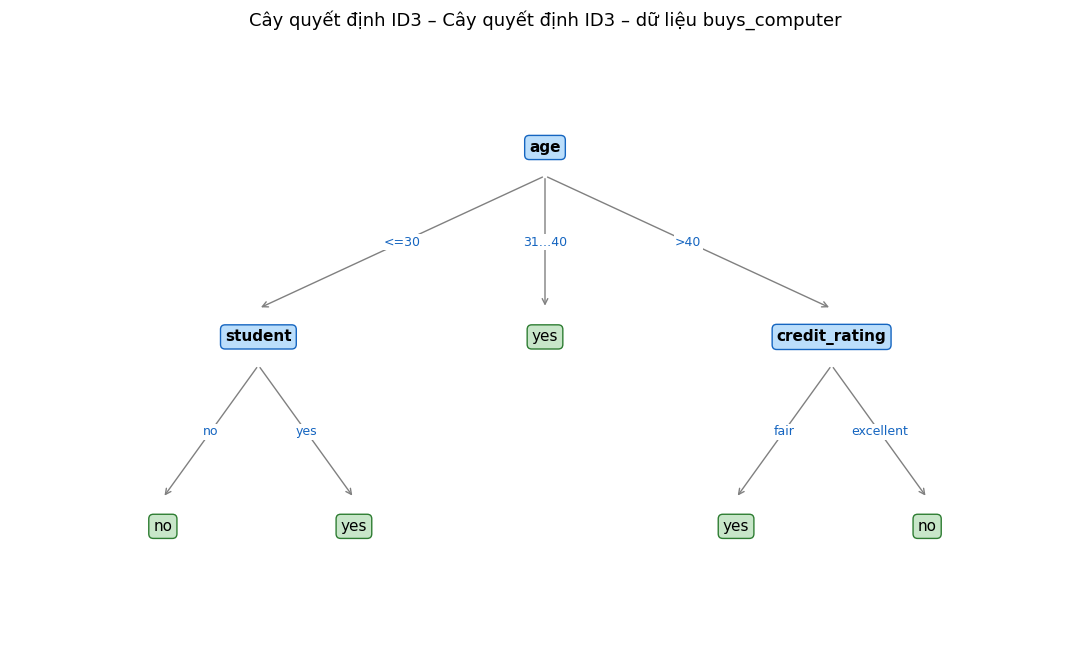

In [7]:
# ===== Vẽ cây bằng matplotlib =====
def count_leaves(node):
    return 1 if "label" in node else sum(count_leaves(c) for c in node["children"].values())

def depth_of(node):
    return 0 if "label" in node else 1 + max(depth_of(c) for c in node["children"].values())

def plot_tree_id3(tree, title):
    W, D = count_leaves(tree), depth_of(tree)
    fig, ax = plt.subplots(figsize=(max(8, 2.2 * W), 2.2 * (D + 1)))
    ax.axis("off")
    x_next = [0]

    def draw(node, depth):
        y = D - depth
        if "label" in node:
            x = x_next[0]; x_next[0] += 1
            ax.text(x, y, str(node["label"]), ha="center", va="center", fontsize=11,
                    bbox=dict(boxstyle="round", fc="#c8e6c9", ec="#2e7d32"))
            return x
        xs = []
        for v, child in node["children"].items():
            cx = draw(child, depth + 1)
            xs.append((cx, v))
        x = np.mean([c for c, _ in xs])
        for cx, v in xs:
            ax.annotate("", xy=(cx, y - 1 + 0.15), xytext=(x, y - 0.15),
                        arrowprops=dict(arrowstyle="->", color="gray"))
            ax.text((x + cx) / 2, y - 0.5, str(v), ha="center", va="center", fontsize=9,
                    color="#1565c0", bbox=dict(fc="white", ec="none", pad=1))
        ax.text(x, y, node["attr"], ha="center", va="center", fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round", fc="#bbdefb", ec="#1565c0"))
        return x

    draw(tree, 0)
    ax.set_xlim(-0.8, W - 0.2); ax.set_ylim(-0.6, D + 0.6)
    ax.set_title(title, fontsize=13)
    plt.tight_layout(); plt.show()

plot_tree_id3(tree, "Cây quyết định ID3 – Cây quyết định ID3 – dữ liệu buys_computer")

### Bước 6: Tập luật IF–THEN

In [8]:
for i, (conds, label) in enumerate(extract_rules(tree), 1):
    print(f"Luật {i}: IF " + " AND ".join(conds) + f" THEN {TARGET} = {label}")

Luật 1: IF age = <=30 AND student = no THEN buys_computer = no
Luật 2: IF age = <=30 AND student = yes THEN buys_computer = yes
Luật 3: IF age = 31…40 THEN buys_computer = yes
Luật 4: IF age = >40 AND credit_rating = fair THEN buys_computer = yes
Luật 5: IF age = >40 AND credit_rating = excellent THEN buys_computer = no


### Bước 7: Dự đoán cho mẫu mới

In [9]:
# Mẫu mới: khách hàng <=30 tuổi, thu nhập medium, là sinh viên, tín dụng fair
new_sample = {"age": "<=30", "income": "medium", "student": "yes", "credit_rating": "fair"}
print("Mẫu mới:", new_sample)
print("Đường đi trên cây:")
predict_one(tree, new_sample, explain=True)

Mẫu mới: {'age': '<=30', 'income': 'medium', 'student': 'yes', 'credit_rating': 'fair'}
Đường đi trên cây:
  age = <=30
  student = yes
  => Nhãn dự đoán: yes


'yes'

### Kiểm tra: độ chính xác trên tập huấn luyện

In [10]:
y_pred = predict(tree, data[ATTRS])
acc = np.mean(np.array(y_pred) == data[TARGET].values)
print(f"Độ chính xác trên tập huấn luyện: {acc:.2%}")

Độ chính xác trên tập huấn luyện: 100.00%


## Nhận xét
- Thuộc tính **age** có Gain lớn nhất (0.247) nên được chọn làm nút gốc. Nhánh `31…40` thuần nhất (cả 4 mẫu đều `yes`) nên thành lá.
- Nhánh `<=30` được chia tiếp theo **student** (Gain = 0.971): sinh viên thì mua, không phải sinh viên thì không mua. Nhánh `>40` được chia theo **credit_rating** (Gain = 0.971): tín dụng `fair` thì mua, `excellent` thì không.
- Cây chỉ có 2 tầng, 5 lá và 5 luật. Thuộc tính **income** không xuất hiện trong cây, tức là không cần thiết để phân loại tập dữ liệu này.
- Cây phân loại đúng 100% tập huấn luyện. Tuy nhiên, với chỉ 14 mẫu, kết quả này chưa đủ để khẳng định cây dự đoán tốt trên dữ liệu mới.